In [1]:
!pip install -q -e ../../relatipy

In [170]:
import relatipy.numeric as rn
import relatipy.visualization as vis
import numpy as np
import matplotlib.pyplot as plt

In [171]:
kerr = rn.metrics.Kerr(a=0.5, mass=1)

In [172]:
isco_prograde = kerr.isco_prograde
isco_retrograde = kerr.isco_retrograde
R_s = kerr.R_s

In [187]:
ics = rn.coordinates.OrbitalElements(
    t=0,
    a=5*isco_prograde,
    e=0,
    inc=0,
    Omega=0,
    omega=0,
    f=0,
    mass=1
)
P = ics._get_period()
print(P)

611.7974561486187


In [188]:
taus = (0, 10*P)
path = kerr.geodesic.get_path(ics, taus, integrator="Radau")
from relatipy.visualization._3D.plot_black_hole import PlotKerr
plot = PlotKerr(kerr)
plot.add_path(path, label="orbit")
plot.plot().show()

# save ../figures/003-integradores_a_largo_plazo/orbit.png as plotly html
plot.plot().write_html("../figures/003-integradores_a_largo_plazo/orbit.html")


In [8]:
# print(path.state_vector)

In [9]:
ics = rn.coordinates.OrbitalElements(
    t=0,
    a=100*R_s,
    e=0,
    inc=10,
    Omega=0,
    omega=0,
    f=0,
    mass=1
)
P = ics._get_period()

taus = (0, 500*P)
path = kerr.geodesic.get_path(ics, taus).convert_to("BoyerLindquist", a=kerr.a)

/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


In [12]:
import os
import pickle

# Define the filename for cached data
cache_filename = "ics_paths_cache.pkl"

if os.path.exists(cache_filename):
    # Try loading the data from file
    with open(cache_filename, "rb") as f:
        data = pickle.load(f)
    ics_ = data["ics_"]
    Ps = data["Ps"]
    paths = data["paths"]
    print("Loaded ics_, Ps, and paths from cache.")
else:
    # If cache file does not exist, compute and save
    ics_ = [
        rn.coordinates.OrbitalElements(
            t=0,
            a=100*R_s,
            e=0,
            inc=inc,
            Omega=0,
            omega=0,
            f=0,
            mass=1
        )
        for inc in [10*i for i in range(10)]
    ]

    Ps = [ics_i._get_period() for ics_i in ics_]

    paths = [kerr.geodesic.get_path(ics_i, taus).convert_to("BoyerLindquist", a=kerr.a) for ics_i in ics_]

    with open(cache_filename, "wb") as f:
        pickle.dump({"ics_": ics_, "Ps": Ps, "paths": paths}, f)
    print("Computed and saved ics_, Ps, and paths to cache.")

Loaded ics_, Ps, and paths from cache.


In [157]:
from relatipy.visualization._2D import SciSubplot
import numpy as np

def plot_errors(workspace, path, P, taus, label=""):
    fig, axs = workspace.fig, workspace.axs

    muestreo = 1000

    times = path[0][::muestreo]/P
    get_absolute_error = lambda x: abs((x - x[0]) / x[0])*100

    results = []
    labels = [
        {'values': lambda p: p._get_Q(kerr)[::muestreo], 'ax': 0, 'ylabel': r"Relative error in $Q$ (%)"},
        {'values': lambda p: p._get_E(kerr)[::muestreo], 'ax': 1, 'ylabel': r"Relative error in $E$ (%)"},
        {'values': lambda p: p._get_Lz(kerr)[::muestreo], 'ax': 2, 'ylabel': r"Relative error in $L_z$ (%)"},
    ]
    for i, l in enumerate(labels):
        values = l['values'](path)
        errors = get_absolute_error(values)

        # Dibujar puntos y guardar el color
        point_line = axs[i].plot(times, errors, ".", label=label if i == 0 else "")
        color = point_line[0].get_color()

        axs[i].set_xlim(taus[0]/P, taus[1]/P)
        axs[i].set_ylabel(l['ylabel'])
        if i == 2:
            axs[i].set_xlabel("Time (periods)")

        try:
            slope, intercept = np.polyfit(times, errors, 1)
            fit_line = slope * times + intercept

            # Misma escala de ejes, línea fina, discontinua y detrás de los puntos
            axs[i].plot(
                times,
                fit_line,
                linestyle="--",
                linewidth=1.0,
                color=color,
                zorder=point_line[0].get_zorder() - 1,
            )
        except Exception as e:
            # Si ocurre un error, como SVD did not converge, devolver np.nan y loggear
            slope = np.nan
            intercept = np.nan
            print(f"Warning in polyfit for {l['ylabel']}: {e}")
        results.append(slope)

    # Dejamos las tiks pero ocultamos los números de los ejes x en axs[0] y axs[1]
    axs[0].set_xticklabels([])
    axs[1].set_xticklabels([])
    # Pegamos los 3 axs (que no se encuentre espacio entre ellos)
    fig.subplots_adjust(hspace=0)  # Elimina el espacio vertical entre los subplots

    if label != "":
        pass

    return tuple(results)

/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/numpy/lib/_polynomial_impl.py:674: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


Warning in polyfit for Relative error in $Q$ (%): SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
Warning in polyfit for Relative error in $E$ (%): SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
Warning in polyfit for Relative error in $L_z$ (%): SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value


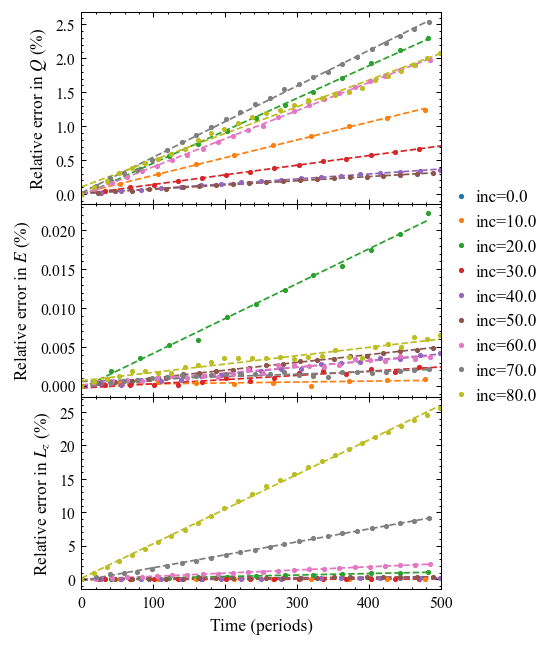

In [164]:
workspace = SciSubplot(figsize=(5, 6), subplot=(3,1))
fig, axs = workspace.fig, workspace.axs

slopes_Q = []
slopes_E = []
slopes_Lz = []
incs_ = []

for i, path in enumerate(paths[:-1]):
    slope_Q, slope_E, slope_Lz = plot_errors(workspace, path, Ps[i], taus, f"inc={ics_[i].inc}")
    slopes_Q.append(slope_Q)
    slopes_E.append(slope_E)
    slopes_Lz.append(slope_Lz)
    incs_.append(ics_[i].inc)

# Solo mostramos la leyenda una vez usando etiquetas únicas para evitar duplicados
# y las colocamos fuera del área del gráfico sin superposición
handles, labels_ = axs[0].get_legend_handles_labels()
unique = dict(zip(labels_, handles))
fig.legend(
    unique.values(), unique.keys(),
    loc='center left',
    bbox_to_anchor=(0.70, 0.5),
    frameon=False,
    borderaxespad=0,
    labelspacing=0.5,
    handletextpad=0.1,
    ncol=1,
    fontsize='medium'
)
fig.subplots_adjust(right=0.7)

# fig.drawn()
fig.savefig("../figures/003-integradores_a_largo_plazo/errors_Q_E_Lz.png")

In [229]:
from joblib import Parallel, delayed
import os
import pickle
import sys

def compute_slopes_for_inc(inc_deg):
    # Condiciones iniciales para esta inclinación
    ics = rn.coordinates.OrbitalElements(
        t=0,
        a=100*R_s,
        e=0,
        inc=inc_deg,
        Omega=0,
        omega=0,
        f=0,
        mass=1,
    )
    P = ics._get_period()
    taus = (0, 500*P)
    path = kerr.geodesic.get_path(ics, taus).convert_to("BoyerLindquist", a=kerr.a)

    # Workspace para usar plot_errors (mismo patrón que antes)
    workspace = SciSubplot(figsize=(8, 6), subplot=(3, 1))
    sQ, sE, sLz = plot_errors(workspace, path, P, taus, label=f"{inc_deg}°")
    plt.close(workspace.fig)

    return inc_deg, sQ, sE, sLz

def get_or_compute_slopes(save=False, filename="slopes_Q_E_Lz_incs.pkl"):
    # Detecta si se está corriendo como proceso hijo (subproceso)
    if hasattr(sys, 'ps1'):
        # Modo interactivo, probablemente no un subproceso
        running_as_child = False
    else:
        # Si 'joblib' ha lanzado este proceso, estará la variable de entorno
        running_as_child = any(kw in os.environ for kw in [
            'JOBLIB_PARALLEL', "LOKY_MAX_CPU_COUNT", "LOKY_CHILD"
        ])

    if running_as_child:
        print(f"⚡️ [Proceso paralelo] Calculando para la petición del proceso principal...", flush=True)

    if os.path.exists(filename) and not save:
        with open(filename, "rb") as f:
            cache = pickle.load(f)
        return cache['incs_'], cache['slopes_Q'], cache['slopes_E'], cache['slopes_Lz']
    else:
        incs_ = list(range(0, 91, 2))
        # Cálculo en paralelo
        print("⏳ Calculando slopes para cada inclinación... (esto puede tardar)", flush=True)
        results = Parallel(n_jobs=-1, backend="loky")(
            delayed(compute_slopes_for_inc)(inc) for inc in incs_
        )
        print("✅ ¡Cálculo terminado!", flush=True)
        # Ordenamos por inclinación y desempaquetamos
        results.sort(key=lambda x: x[0])
        incs_ = np.array([r[0] for r in results])
        slopes_Q = np.array([r[1] for r in results])
        slopes_E = np.array([r[2] for r in results])
        slopes_Lz = np.array([r[3] for r in results])
        # Guardar resultado
        cache = {
            'incs_': incs_,
            'slopes_Q': slopes_Q,
            'slopes_E': slopes_E,
            'slopes_Lz': slopes_Lz
        }
        with open(filename, "wb") as f:
            pickle.dump(cache, f)
        return incs_, slopes_Q, slopes_E, slopes_Lz

# Uso principal:
# Si queremos recalcular y guardar de nuevo, usar get_or_compute_slopes(save=True)
# Por defecto, solo carga si existe
incs_, slopes_Q, slopes_E, slopes_Lz = get_or_compute_slopes()

⏳ Calculando slopes para cada inclinación... (esto puede tardar)


python(94038) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94039) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94040) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94041) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94042) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94043) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94044) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94045) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


** On entry to DLASCL, parameter number  4 had an illegal value
Warning in polyfit for Relative error in $Q$ (%): SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
Warning in polyfit for Relative error in $E$ (%): SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
Warning in polyfit for Relative error in $L_z$ (%): SVD did not converge in Linear Least Squares


/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/numpy/lib/_polynomial_impl.py:674: RuntimeWarning: invalid value encountered in divide
  lhs /= scale
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow 

✅ ¡Cálculo terminado!


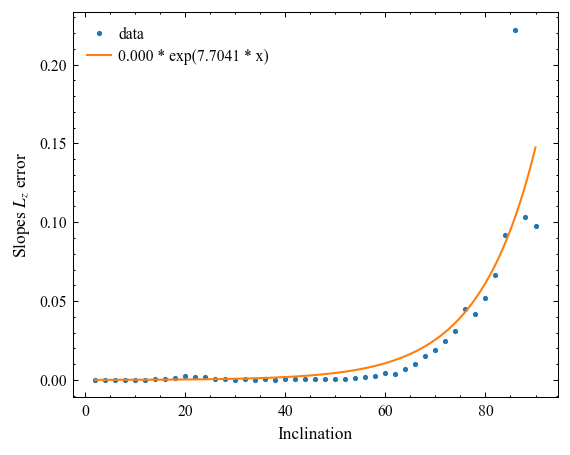

In [258]:
from scipy.optimize import curve_fit

slope = slopes_Lz

def piecewise_fit(x, a, b):
    # x = np.asarray(x)
    # out = np.empty_like(x, dtype=float)
    # mask = x < 0.75  # 60/80 normalizado
    # out[mask] = a * x[mask] + b
    # out[~mask] = c * x[~mask] + d
    # return out
    return a * np.exp(b * x)

# Quitar NaNs
mask = ~np.isnan(slope)
incs_clean = incs_[mask]
slope_clean = slope[mask]

# Normalizar x e y
incs_min, incs_max = incs_clean.min(), incs_clean.max()
slope_min, slope_max = slope_clean.min(), slope_clean.max()

incs_normalized = (incs_clean - incs_min) / (incs_max - incs_min)
slope_normalized = (slope_clean - slope_min) / (slope_max - slope_min)

popt, _ = curve_fit(piecewise_fit, incs_normalized, slope_normalized)

# Desnormalizar fit
incs_fine_norm = np.linspace(0, 1, 200)
incs_fine = incs_fine_norm * (incs_max - incs_min) + incs_min
slope_fit = piecewise_fit(incs_fine_norm, *popt) * (slope_max - slope_min) + slope_min

workspace = SciSubplot(figsize=(5, 4))
fig, ax = workspace.fig, workspace.ax

ax.plot(incs_clean, slope_clean, ".", label="data")
ax.plot(incs_fine, slope_fit, "-", label=f"{popt[0]:.3f} * exp({popt[1]:.4f} * x)")
ax.set_xlabel("Inclination")
ax.set_ylabel("Slopes $L_z$ error")
# plt.title("Slopes $L_z$ — ajuste lineal a tramos")
ax.legend()
fig.savefig("../figures/003-verificacion_de_comportamiento_esperado/slopes_Lz_error_piecewise.png")

/var/folders/8g/jy3rvzr50kv5w6g24cxmq6kc0000gp/T/ipykernel_76999/2853578952.py:6: RuntimeWarning: divide by zero encountered in power
  return a*np.sin(b*x + c) * (x**d + x**e) + f*x**2 + g*x + h


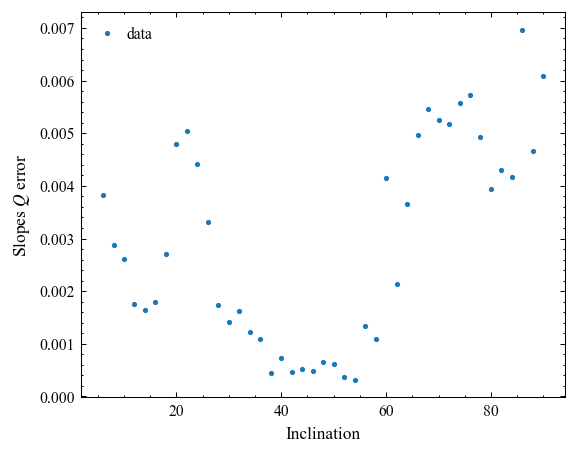

In [260]:
from scipy.optimize import curve_fit

slope = slopes_Q[3:]

def exp_fit(x, a, b, c, d, e, f, g, h):
    return a*np.sin(b*x + c) * (x**d + x**e) + f*x**2 + g*x + h

# Quitar NaNs
mask = ~np.isnan(slope)
incs_clean = incs_[3:][mask]
slope_clean = slope[mask]

# Normalizar x e y
incs_min, incs_max = incs_clean.min(), incs_clean.max()
slope_min, slope_max = slope_clean.min(), slope_clean.max()

incs_normalized = (incs_clean - incs_min) / (incs_max - incs_min)
slope_normalized = (slope_clean - slope_min) / (slope_max - slope_min)

popt, _ = curve_fit(exp_fit, incs_normalized, slope_normalized, maxfev=10000)

# Desnormalizar fit
incs_fine_norm = np.linspace(0, 1, 200)
incs_fine = incs_fine_norm * (incs_max - incs_min) + incs_min
slope_fit = exp_fit(incs_fine_norm, *popt) * (slope_max - slope_min) + slope_min

workspace = SciSubplot(figsize=(5, 4))
fig, ax = workspace.fig, workspace.ax

ax.plot(incs_clean, slope_clean, ".", label="data")
# plt.plot(incs_fine, slope_fit, "-", label=f"a={popt[0]:.3f}, b={popt[1]:.4f}, c={popt[2]:.4f}, d={popt[3]:.4f}")
# plt.xlabel("Inclinación")
ax.set_xlabel("Inclination")
ax.set_ylabel("Slopes $Q$ error")
# plt.title("Slopes $Q$ — ajuste $a\\sin(bx)\\cos(cx)+d$")
ax.legend()
fig.savefig("../figures/003-verificacion_de_comportamiento_esperado/slopes_Q_error_exp.png")
plt.show()

/var/folders/8g/jy3rvzr50kv5w6g24cxmq6kc0000gp/T/ipykernel_76999/623602835.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


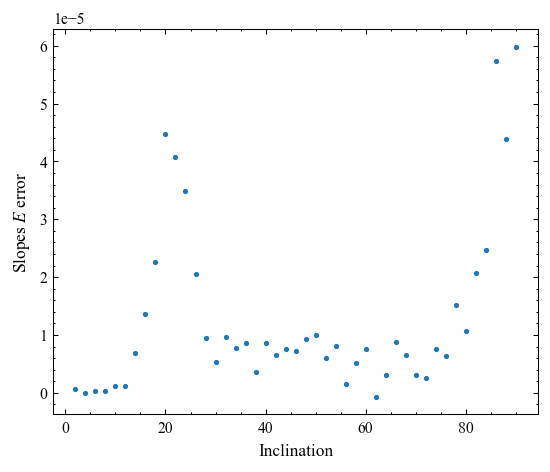

In [261]:
workspace = SciSubplot(figsize=(5, 4))
fig, ax = workspace.fig, workspace.ax

ax.plot(incs_, slopes_E, ".")

ax.set_xlabel("Inclination")
ax.set_ylabel("Slopes $E$ error")
ax.legend()
fig.savefig("../figures/003-verificacion_de_comportamiento_esperado/slopes_E_error_exp.png")


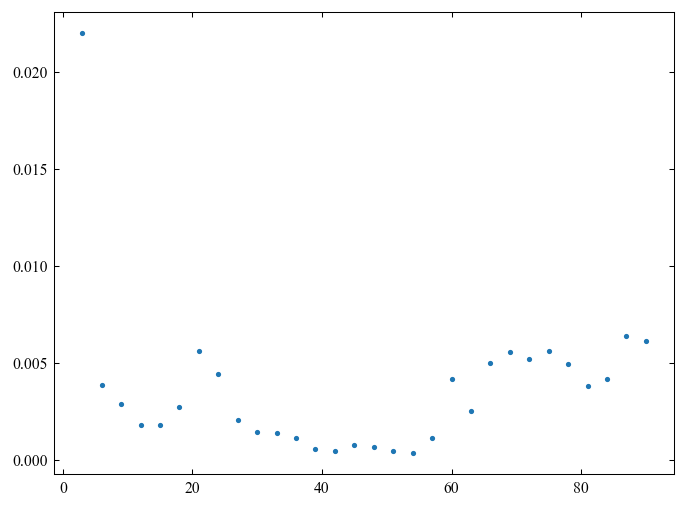

In [220]:
plt.plot(incs_, slopes_Q, ".")
# plt.plot(incs_, slopes_E, ".")
# plt.plot(incs_, slopes_Lz, ".")


(0.0, 10.0)

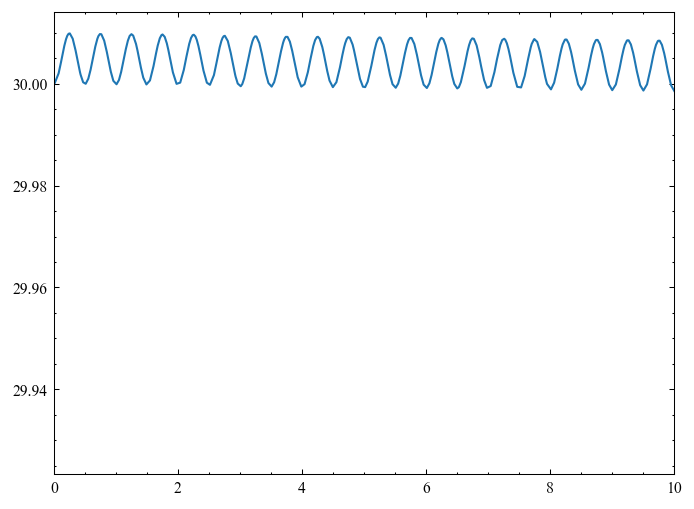

In [15]:
# Plot inclinación vs periodo
from re import M


work = SciSubplot()
fig, ax = work.fig, work.ax

for i, path in enumerate([paths[3]]):
    inc = path.convert_to("OrbitalElements", mass=1).inc
    times = path[0]/Ps[i]
    ax.plot(times, inc, "-", label=f"inc={ics_[i].inc}")

ax.set_xlim(0, 10)

In [56]:
import numpy as np
from scipy.signal import lombscargle
import matplotlib.pyplot as plt
import os
import pickle

lombscargle_cache_filename = "cache_lombscargle.pkl"

if os.path.exists(lombscargle_cache_filename):
    with open(lombscargle_cache_filename, "rb") as f:
        lombscargle_results = pickle.load(f)
    print("Loaded Lomb-Scargle results from cache.")
    all_freqs = lombscargle_results['all_freqs']
    all_powers = lombscargle_results['all_powers']
else:
    print("Lomb-Scargle cache not found. Calculating and saving...")
    all_freqs = []
    all_powers = []

    for i, path in enumerate(paths[:]):
        inc = path.convert_to("OrbitalElements", mass=1).inc
        times = path[0]/Ps[i]

        t = times
        y = inc - np.mean(inc)  # 1. SIEMPRE restar la media

        # 2. Definir un mallado de frecuencias más fino si es necesario
        # (Depende de cuánto tiempo total abarquen tus datos)
        freqs = np.linspace(0.1, 10, 1200) 
        angular_freqs = 2 * np.pi * freqs

        # 3. Calcular Lomb-Scargle
        power_raw = lombscargle(t, y, angular_freqs)

        all_freqs.append(freqs)
        all_powers.append(power_raw)

    with open(lombscargle_cache_filename, "wb") as f:
        pickle.dump({'all_freqs': all_freqs, 'all_powers': all_powers}, f)
    print("Saved Lomb-Scargle results to cache.")


Loaded Lomb-Scargle results from cache.


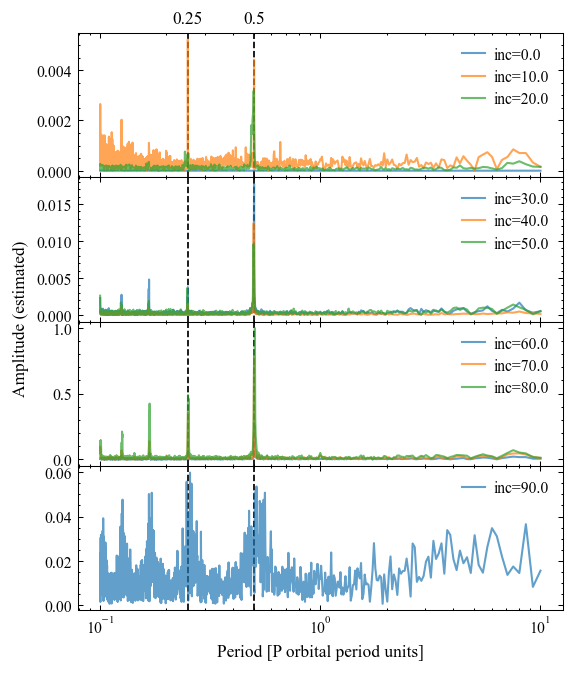

In [165]:
import numpy as np
from scipy.signal import lombscargle
import matplotlib.pyplot as plt

workspace = SciSubplot(subplot=(4, 1), figsize=(5, 6))
fig, axs = workspace.fig, workspace.axs

# Valores de periodo en los que queremos líneas
periodos_linea = [0.25, 0.5]
# Poner líneas verticales en los cuatro subplots (ax[0] a ax[3]) en periodos 0.25 y 0.5
for ax in axs:
    for xval in periodos_linea:
        ax.axvline(x=xval, color='k', linestyle='--', alpha=1, lw=1)

for i in range(len(all_freqs)):
    # Calculamos el periodo: 1 / frecuencia
    periodos = 1 / all_freqs[i]
    
    # Calculamos la amplitud (Ojo: asegúrate que len(all_freqs[i]) sea el N de tus datos originales)
    amplitud = np.sqrt(4 * all_powers[i] / len(all_freqs[i]))
    
    # Graficamos Periodo vs Amplitud
    axs[i // 3].plot(periodos, amplitud, label=f"inc={ics_[i].inc}", alpha=0.7)


for i, ax in enumerate(axs):
    ax.legend()
    ax.set_xscale("log")
    if i != 3:
        ax.set_xticklabels([])

# Encima del primer cuadro (axs[0]) escribimos los valores
ymax0 = axs[0].get_ylim()[1]
for idx, xval in enumerate(periodos_linea):
    axs[0].annotate(
        f"{xval}",
        xy=(xval, ymax0), xycoords=("data", "data"),
        xytext=(0, 3), textcoords="offset points",
        ha="center", va="bottom", fontsize=10, color='k', alpha=1
    )

axs[3].set_xlabel("Period [P orbital period units]")
fig.text(0.02, 0.5, "Amplitude (estimated)", va="center", rotation="vertical")

fig.subplots_adjust(hspace=0)

fig.savefig("../figures/003-integradores_a_largo_plazo/periodograma_inclinacion.png")

Usando las 50 frecuencias dominantes:
1: f = 3.906422 -> P = 0.255989
2: f = 4.046789 -> P = 0.247109
3: f = 3.848624 -> P = 0.259833
4: f = 1.949541 -> P = 0.512941
5: f = 1.784404 -> P = 0.560411
6: f = 5.830275 -> P = 0.171518
7: f = 1.982569 -> P = 0.504396
8: f = 6.003670 -> P = 0.166565
9: f = 7.911009 -> P = 0.126406
10: f = 1.809174 -> P = 0.552738
11: f = 1.883486 -> P = 0.530930
12: f = 1.941284 -> P = 0.515123
13: f = 1.833945 -> P = 0.545273
14: f = 1.875229 -> P = 0.533268
15: f = 2.106422 -> P = 0.474739
16: f = 3.988991 -> P = 0.250690
17: f = 3.914679 -> P = 0.255449
18: f = 7.977064 -> P = 0.125359
19: f = 1.792661 -> P = 0.557830
20: f = 3.939450 -> P = 0.253843
21: f = 5.863303 -> P = 0.170552
22: f = 9.686239 -> P = 0.103239
23: f = 5.846789 -> P = 0.171034
24: f = 1.974312 -> P = 0.506506
25: f = 3.642202 -> P = 0.274559
26: f = 6.044954 -> P = 0.165427
27: f = 5.813761 -> P = 0.172006
28: f = 0.116514 -> P = 8.582677
29: f = 3.865138 -> P = 0.258723
30: f = 2.0568

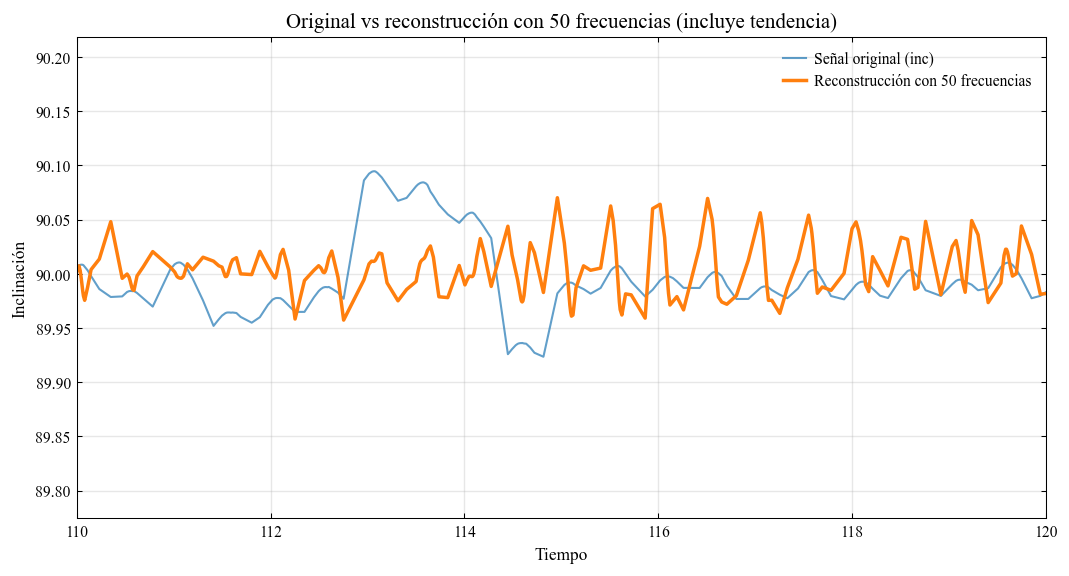

In [94]:
import numpy as np
from scipy.signal import lombscargle
import matplotlib.pyplot as plt

# --- Parámetro que puedes cambiar ---
N = 50  # número de frecuencias dominantes a usar
# -----------------------------------

# t e inc como antes
t = times
inc = path.convert_to("OrbitalElements", mass=1).inc

# 1) Ajustar y quitar tendencia lineal
p = np.polyfit(t, inc, 1)      # recta: p[0]*t + p[1]
trend = np.polyval(p, t)
y = inc - trend                # señal sin tendencia

# 2) Lomb–Scargle con y
freqs = np.linspace(0.1, 10, 1200)
w = 2 * np.pi * freqs
power_raw = lombscargle(t, y, w)

# 3) Seleccionar las N frecuencias dominantes
idx_sorted = np.argsort(power_raw)[::-1]
idx_top = idx_sorted[:N]
freqs_top = freqs[idx_top]
w_top = 2 * np.pi * freqs_top

print(f"Usando las {N} frecuencias dominantes:")
for k, f in enumerate(freqs_top, start=1):
    print(f"{k}: f = {f:.6f} -> P = {1/f:.6f}")

# 4) Matriz de diseño con senos y cosenos para cada frecuencia
cols = []
for w_i in w_top:
    cols.append(np.sin(w_i * t))
    cols.append(np.cos(w_i * t))
A = np.vstack(cols).T  # shape: (len(t), 2N)

# 5) Ajuste por mínimos cuadrados: y ≈ A @ coef
coef, *_ = np.linalg.lstsq(A, y, rcond=None)

# 6) Reconstrucción (todavía sin tendencia)
y_rec = A @ coef

# 7) Volver a añadir la tendencia lineal para comparar con inc
inc_rec = y_rec + trend

# 8) Gráfica de comparación con zoom
plt.figure(figsize=(10, 5))
plt.plot(t, inc, label="Señal original (inc)", alpha=0.7)
plt.plot(t, inc_rec, label=f"Reconstrucción con {N} frecuencias", lw=2)
plt.xlabel("Tiempo")
plt.ylabel("Inclinación")
plt.title(f"Original vs reconstrucción con {N} frecuencias (incluye tendencia)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(110, 120)  # zoom en el intervalo pedido
plt.show()